In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

nav = pd.read_csv("data/raw/02_nav_history.csv")
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("data/raw/05_category_inflows.csv")
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
print(nav.columns)
print(aum.columns)
print(sip.columns)
print(category.columns)
print(folio.columns)
print(transactions.columns)
print(holdings.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')
Index(['month', 'category', 'net_inflow_crore'], dtype='str')
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


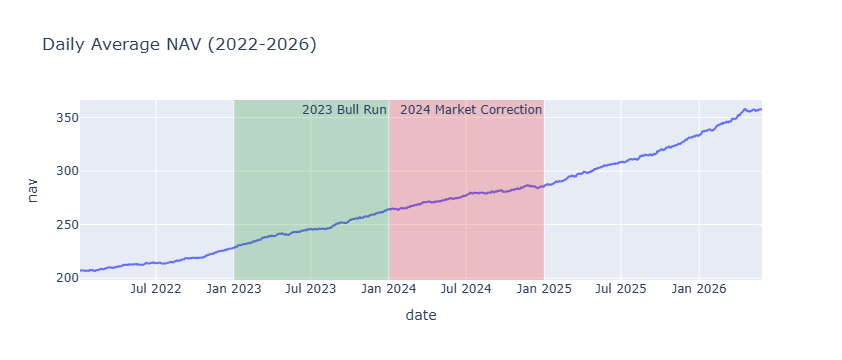

In [4]:
import warnings
warnings.filterwarnings("ignore")

nav["date"] = pd.to_datetime(nav["date"])

daily_nav = nav.groupby("date")["nav"].mean().reset_index()

fig = px.line(
    daily_nav,
    x="date",
    y="nav",
    title="Daily Average NAV (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.2,
    line_width=0
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Market Correction",
    fillcolor="red",
    opacity=0.2,
    line_width=0
)

fig.show()

In [5]:
print(aum.head())
print(aum.dtypes)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
date                  str
fund_house            str
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object


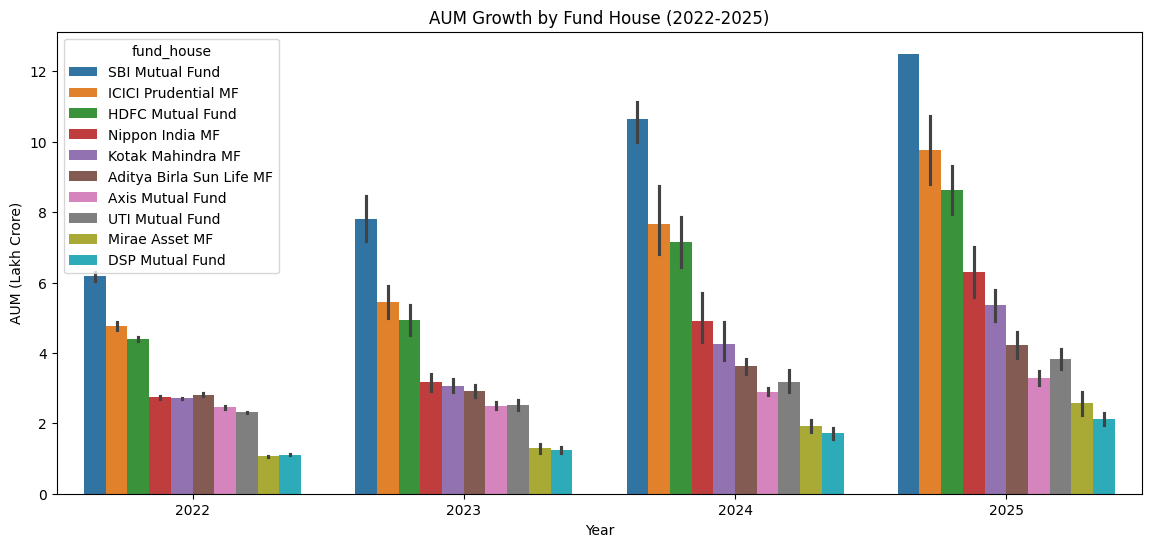

In [6]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.show()

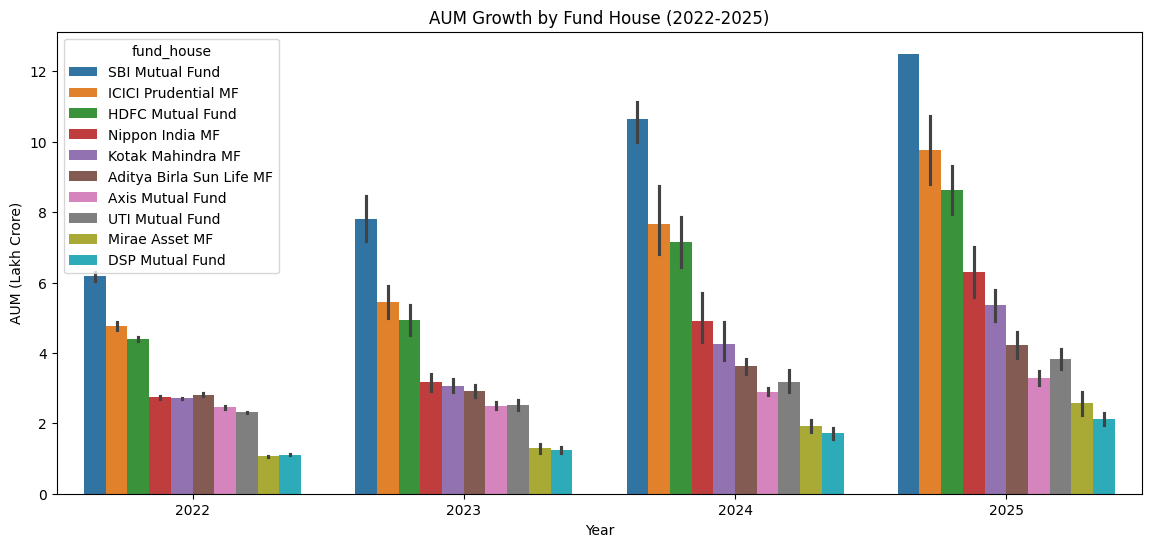

In [7]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.savefig("reports/aum_growth.png", bbox_inches="tight")

plt.show()

### AUM Growth Analysis

SBI Mutual Fund maintained the highest Assets Under Management during the study period. Most fund houses showed steady growth in AUM between 2022 and 2025.

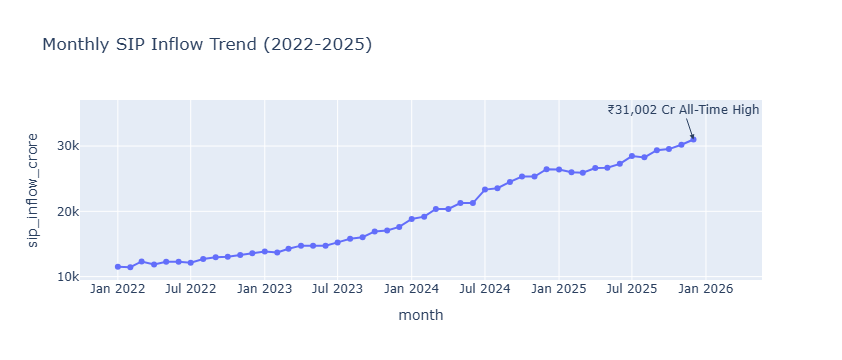

In [8]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022-2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [16]:
fig.write_image("reports/sip_inflow_trend.png")
print("Image saved successfully")

Image saved successfully


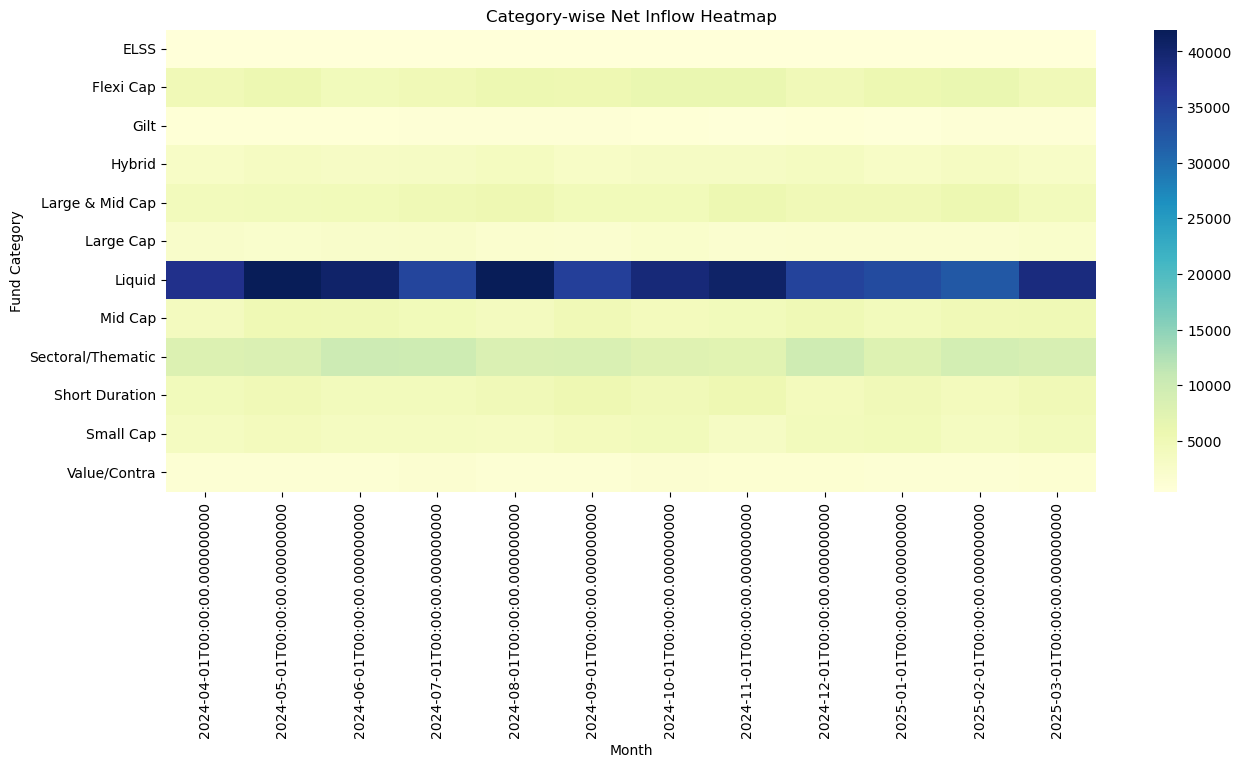

In [13]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(15,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

### Category Inflow Heatmap

The heatmap highlights variations in net inflows across mutual fund categories over time. Equity-oriented categories generally attracted higher inflows compared to debt categories during the study period.

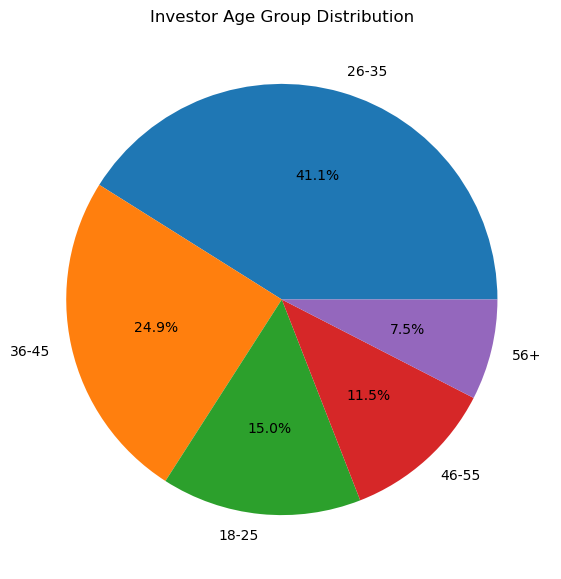

In [15]:
age_data = transactions["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_data,
    labels=age_data.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

### Age Group Distribution

The majority of investors belong to the young and middle-aged categories, indicating strong participation from the working population.

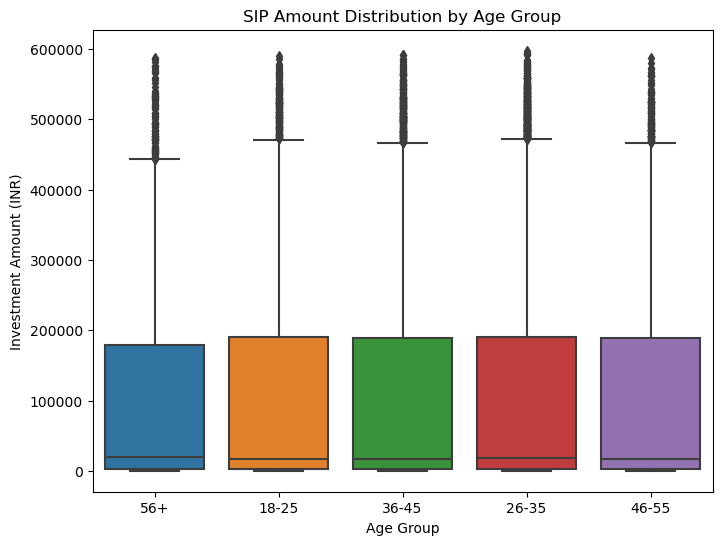

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="age_group",
    y="amount_inr",
    data=transactions
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.show()

### SIP Amount by Age Group

The box plot shows how investment amounts vary across different age groups and helps identify outliers.

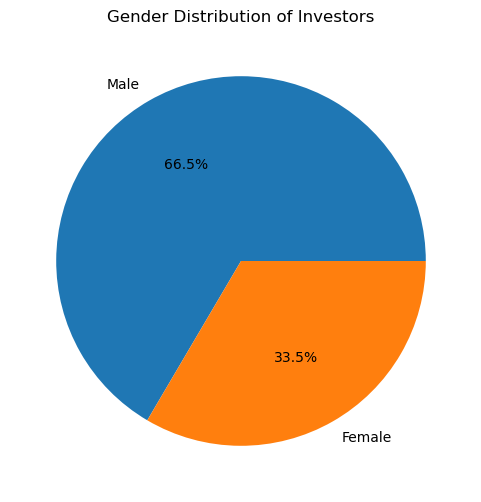

In [17]:
gender_data = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_data,
    labels=gender_data.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")

plt.show()

### Gender Distribution

The investor base includes participation from both genders, with the chart showing their relative proportions.

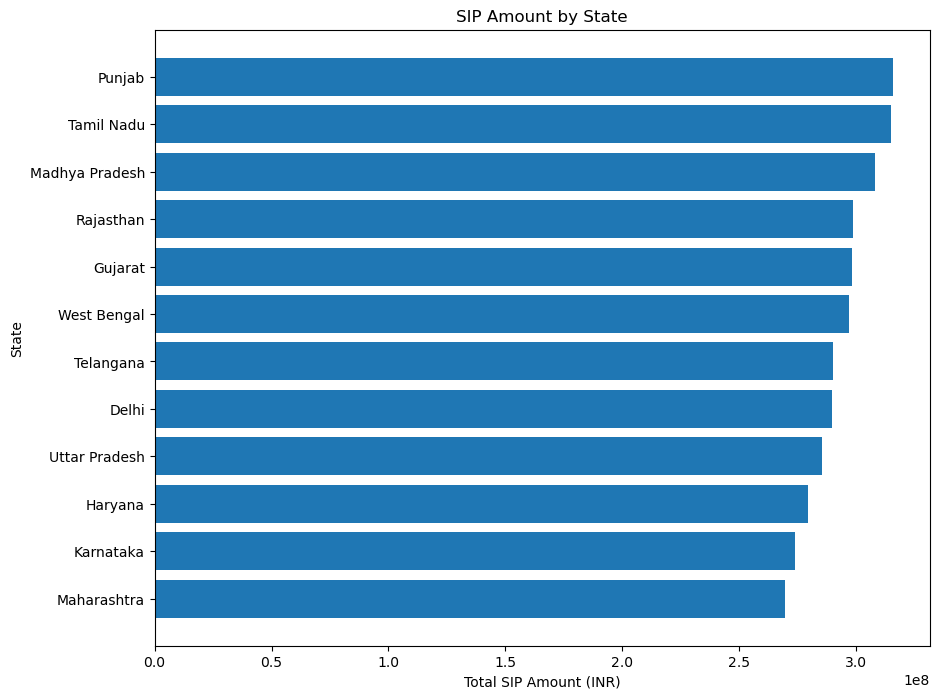

In [18]:
state_data = transactions.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))

plt.barh(
    state_data.index,
    state_data.values
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.show()

### Geographic Distribution by State

The chart shows the total SIP investment amount across different states, highlighting regions with stronger mutual fund participation.

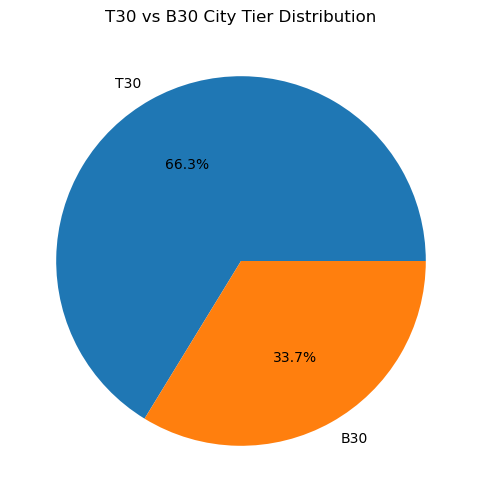

In [19]:
city_data = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_data,
    labels=city_data.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 City Tier Distribution")

plt.show()

### T30 vs B30 Distribution

The pie chart compares investor participation between T30 and B30 cities, providing insights into urban and emerging market penetration.

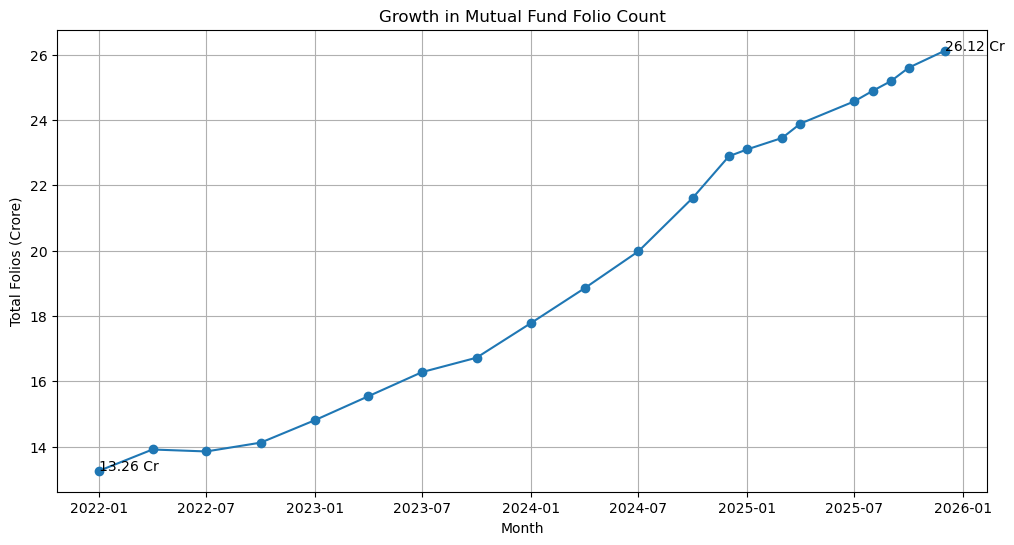

In [20]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Growth in Mutual Fund Folio Count")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.annotate(
    "13.26 Cr",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0])
)

plt.annotate(
    "26.12 Cr",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1])
)

plt.grid(True)

plt.show()

### Folio Count Growth

The total mutual fund folio count showed consistent growth over the analysis period, increasing from around 13.26 crore to more than 26 crore, reflecting expanding investor participation.

In [21]:
nav["date"] = pd.to_datetime(nav["date"])

nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = nav_pivot.pct_change()

In [22]:
selected_returns = daily_returns.iloc[:, :10]

In [23]:
correlation_matrix = selected_returns.corr()

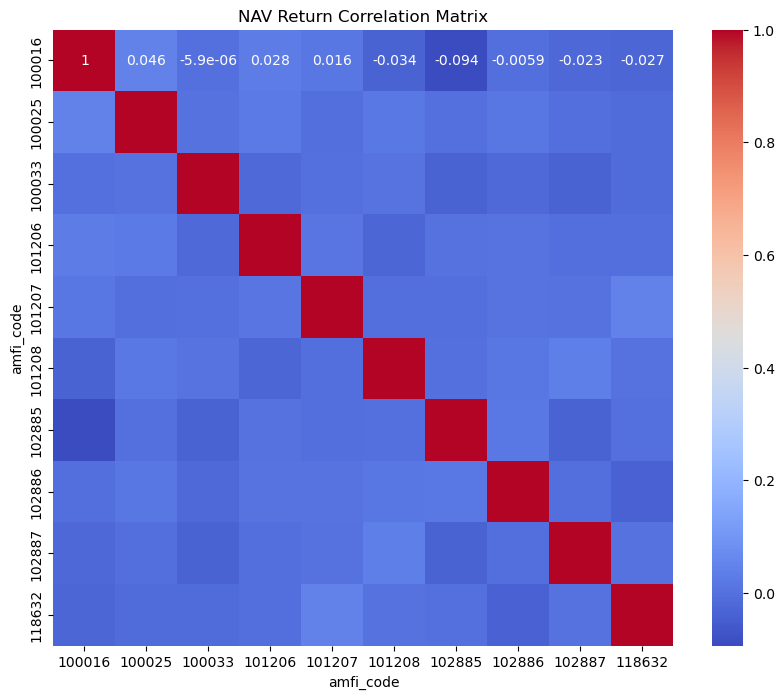

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")
plt.show()

### NAV Return Correlation Matrix

The correlation matrix measures the relationship between daily returns of selected mutual funds. Highly correlated funds tend to move in similar market conditions, while lower correlations indicate diversification opportunities.

In [25]:
sector_data = holdings.groupby("sector")["weight_pct"].sum()

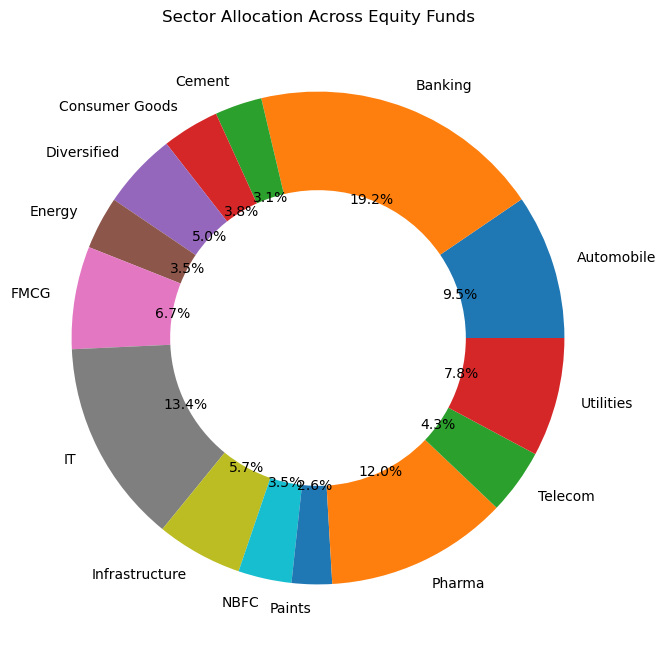

In [26]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

### Sector Allocation Analysis

The sector allocation chart shows the overall distribution of investments across different sectors. It helps identify sectors with higher portfolio concentration and diversification patterns.

### Insight 1

The average NAV of mutual funds showed a positive trend during the analysis period, reflecting overall market growth.

### Insight 2

AUM increased steadily across most fund houses, with SBI Mutual Fund maintaining the highest AUM.

### Insight 3

Monthly SIP inflows grew consistently and reached an all-time high of ₹31,002 crore in December 2025.

### Insight 4

Equity-oriented categories attracted stronger inflows than many debt-oriented categories.

### Insight 5

Young and middle-aged investors contribute a significant share of mutual fund investments.

### Insight 6

Investment amounts vary across age groups, with some groups showing larger investment outliers.

### Insight 7

Investor participation is distributed across both genders, showing a diverse investor base.

### Insight 8

Some states contribute a larger share of SIP investments, indicating regional differences in market participation.

### Insight 9

The total mutual fund folio count almost doubled during the study period, reflecting rapid industry growth.

### Insight 10

Sector allocation analysis shows that portfolios are diversified across multiple sectors, reducing concentration risk.

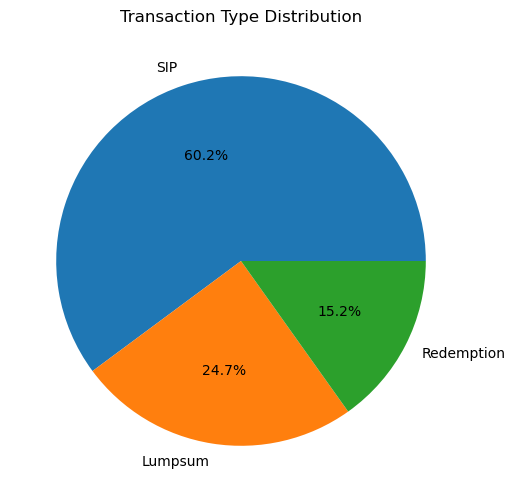

In [27]:
transaction_data = transactions["transaction_type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    transaction_data,
    labels=transaction_data.index,
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")

plt.show()

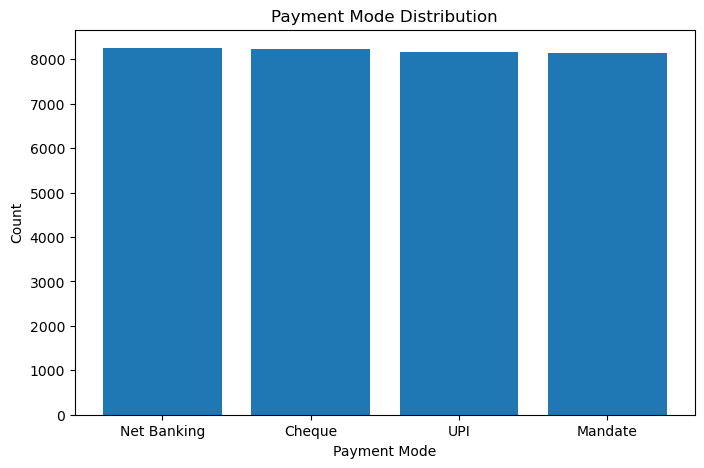

In [28]:
payment_data = transactions["payment_mode"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    payment_data.index,
    payment_data.values
)

plt.title("Payment Mode Distribution")
plt.xlabel("Payment Mode")
plt.ylabel("Count")

plt.show()

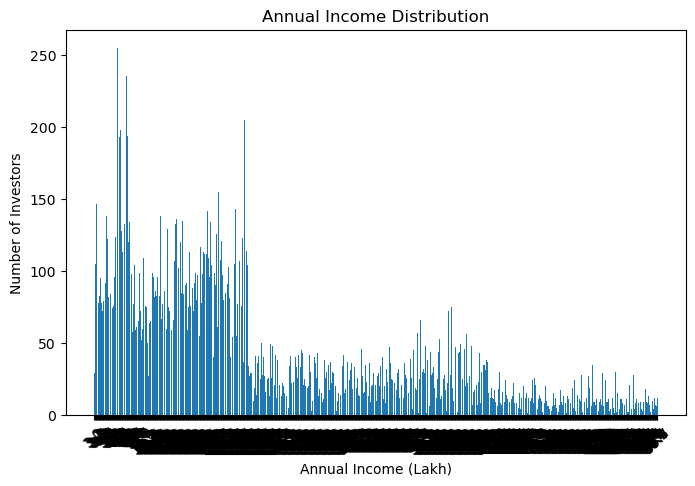

In [31]:
income_data = transactions["annual_income_lakh"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    income_data.index.astype(str),
    income_data.values
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (Lakh)")
plt.ylabel("Number of Investors")

plt.xticks(rotation=45)

plt.show()

In [14]:
import os
print(os.getcwd())

C:\Users\garav\OneDrive\Desktop\Mutual funds


In [17]:
import os
print(os.path.exists("reports/sip_inflow_trend.png"))

True


In [18]:
import os
print(os.listdir("reports"))

['aum_growth.png', 'day1_data_quality_summary.txt', 'sip_inflow_trend.png']


In [19]:
print(os.getcwd())
print(os.path.exists("reports/sip_inflow_trend.png"))

C:\Users\garav\OneDrive\Desktop\Mutual funds
True


In [20]:
fig.write_image("reports/nav_trend.png")
fig.write_image("reports/category_heatmap.png")
fig.write_image("reports/investor_demographics.png")
fig.write_image("reports/geographic_distribution.png")
fig.write_image("reports/folio_growth.png")
fig.write_image("reports/correlation_matrix.png")
fig.write_image("reports/sector_allocation.png")